# NVIDIA Descriptive Analysis

*What happened.* This notebook tells the visual story of NVIDIA's market performance and earnings from 2010 to 2026, alongside the three AI-era bands. Formal break detection and hypothesis tests live in the **diagnostic** notebook; here we describe NVIDIA's own trajectory, its divergence from peers, and the hyperscaler-capex backdrop.

> **Non-causal framing.** Every chart documents *temporal alignment* (where a shift in NVIDIA's series lines up with an AI milestone), not causation. Findings should describe association only.

**Eras:** Pre-Attention / CNN (2010Q1–2017Q2) · Transformer (2017Q3–2022Q3) · Generative-AI (2022Q4–2026Q1). AlexNet (2012Q3) is marked *inside* the first band.

## Setup

In [16]:
import sys
from pathlib import Path

# Walk up to the repo root and put Source/ on the path, so `import common`
# works whether Jupyter is launched from the repo root or this folder.
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "Source" / "common.py").exists():
        sys.path.insert(0, str(_p / "Source")); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import common
import importlib
importlib.reload(common)   # pick up edits to common.py without restarting the kernel
common.apply_style()

panel = common.load_panel()
seg   = common.load_segments()
daily = common.load_daily()

# Save every figure into ./figures next to this notebook.
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)
def save(fig, name): fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

print(f"panel : {panel.shape[0]} rows | {panel['ticker'].nunique()} tickers | "
      f"{panel['calendar_quarter'].min()}-{panel['calendar_quarter'].max()}")
print(f"seg   : {seg.shape[0]} fiscal years | FY{seg['fiscal_year'].min()}-FY{seg['fiscal_year'].max()}")
print(f"daily : {daily.shape[0]} rows | {daily['ticker'].nunique()} tickers")

panel : 577 rows | 9 tickers | 2010Q1-2026Q1
seg   : 13 fiscal years | FY2013-FY2025
daily : 20425 rows | 5 tickers


## Data sanity check
Confirm coverage before plotting: date ranges, per-ticker counts, and how NVIDIA's quarters distribute across the three eras.

In [17]:
cov = (panel.groupby("ticker")
       .agg(rows=("calendar_quarter", "size"),
            first=("calendar_quarter", "min"),
            last=("calendar_quarter", "max"),
            price=("qend_adj_close", lambda s: int(s.notna().sum())),
            revenue=("revenue", lambda s: int(s.notna().sum())),
            capex=("capex", lambda s: int(s.notna().sum()))))
print(cov.to_string())
print("\nNVDA quarters per era:")
print(panel[panel.ticker == "NVDA"]["era"]
      .value_counts().reindex([e.name for e in common.ERAS]).to_string())

        rows   first    last  price  revenue  capex
ticker                                             
AMD       65  2010Q1  2026Q1     65       64      0
AMZN      64  2010Q1  2025Q4      0        0     64
GOOGL     64  2010Q1  2025Q4      0        0     64
INTC      65  2010Q1  2026Q1     65       64      0
META      60  2010Q3  2025Q4      0        0     60
MSFT      64  2010Q1  2025Q4      0        0     64
NDX       65  2010Q1  2026Q1     65        0      0
NVDA      65  2010Q1  2026Q1     65       64      0
SOX       65  2010Q1  2026Q1     65        0      0

NVDA quarters per era:
era
Pre-Attention / CNN    30
Transformer            21
Generative-AI          14


## 1. NVIDIA's own story

NVIDIA on its own terms (price, earnings, segment mix, and margin structure) before any peer comparison. Price and the revenue/income series are on a **linear (raw)** scale, so the Generative-AI surge shows at true magnitude. The segment and margin charts are **annual** (NVIDIA discloses segments only once a year in the 10-K).

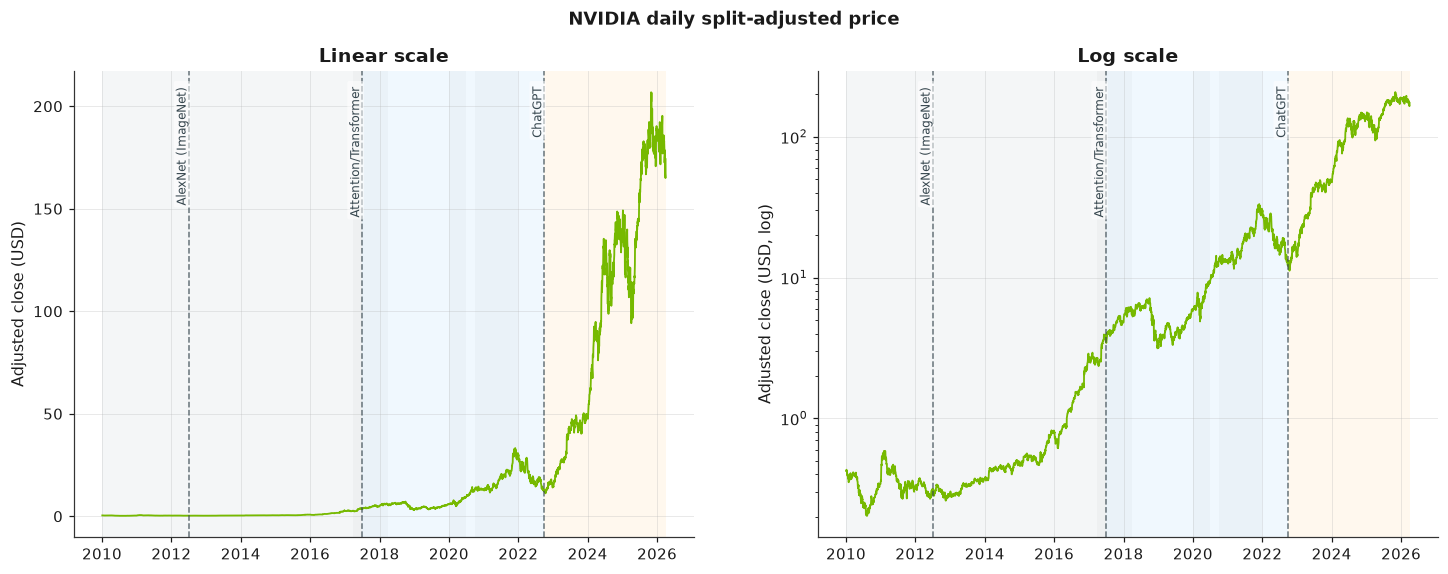

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
nv = daily[daily.ticker == "NVDA"].sort_values("date")

# LEFT: linear
ax1.plot(nv["date"], nv["adj_close"], color=common.color("NVDA"), lw=1.2)
common.annotate(ax1)
common.style_time_axis(ax1)
ax1.set_ylabel("Adjusted close (USD)")
ax1.set_title("Linear scale")

# RIGHT: log
ax2.plot(nv["date"], nv["adj_close"], color=common.color("NVDA"), lw=1.2)
common.annotate(ax2)
common.set_log(ax2)
common.style_time_axis(ax2)
ax2.set_ylabel("Adjusted close (USD, log)")
ax2.set_title("Log scale")

fig.suptitle("NVIDIA daily split-adjusted price", fontweight="bold")
save(fig, "01_price_compare"); plt.show()

NVIDIA's split-adjusted price is shown on two scales. On the linear panel the series is nearly flat for the first decade and then turns close to vertical from 2023, peaking near \$207 before settling around \$174 at the 2026Q1 cut. The log panel tells a different and arguably more honest story: instead of a single late spike, it shows a sustained multi-year climb that begins lifting in the mid-2010s and steepens through each successive era. Measured as a cumulative index from a 2010 base of 100, the price ends the Pre-Attention era near 900, the Transformer era near 3,000, and the Generative-AI era above 43,000.

The scale of the move is easier to feel in two spans. From the start of 2010 (\$0.42, split-adjusted) to the 2026Q1 cut (\$174.20), the price gained \$173.77, a rise of about 411 times, or roughly +41,000 percent. From the end of 2022Q4 (\$14.58), the quarter ChatGPT launched, to the same cut, it gained \$159.62, close to 12 times, or about +1,095 percent. So even measured only from the generative-AI starting line, the price has multiplied roughly twelvefold in a little over three years.

The two panels answer different questions. The linear view captures magnitude, making clear that almost all of the dollar appreciation falls inside the Generative-AI band that opens at the 2022Q4 ChatGPT marker. The log view captures rate, and it lines the steepening up with the earlier Attention/Transformer marker (2017Q3) as well, which suggests the acceleration is not purely a 2022 phenomenon. Read alongside the relative-strength chart (06), where NVIDIA only pulls ahead of the market from about 2016, the log panel's earlier inflection is consistent with a repricing that predates the generative-AI wave.

Two cautions. First, this is split-adjusted price, not market capitalisation or any valuation multiple, so it reflects per-share movement rather than the company's size or how richly it is valued against earnings. Second, the eye is easily pulled by the linear panel into reading the whole story as a single 2022 event; the log panel is the better guide to when the trend actually changed. As everywhere in this study, a price move that lines up with a milestone is alignment, not evidence that the milestone caused it.

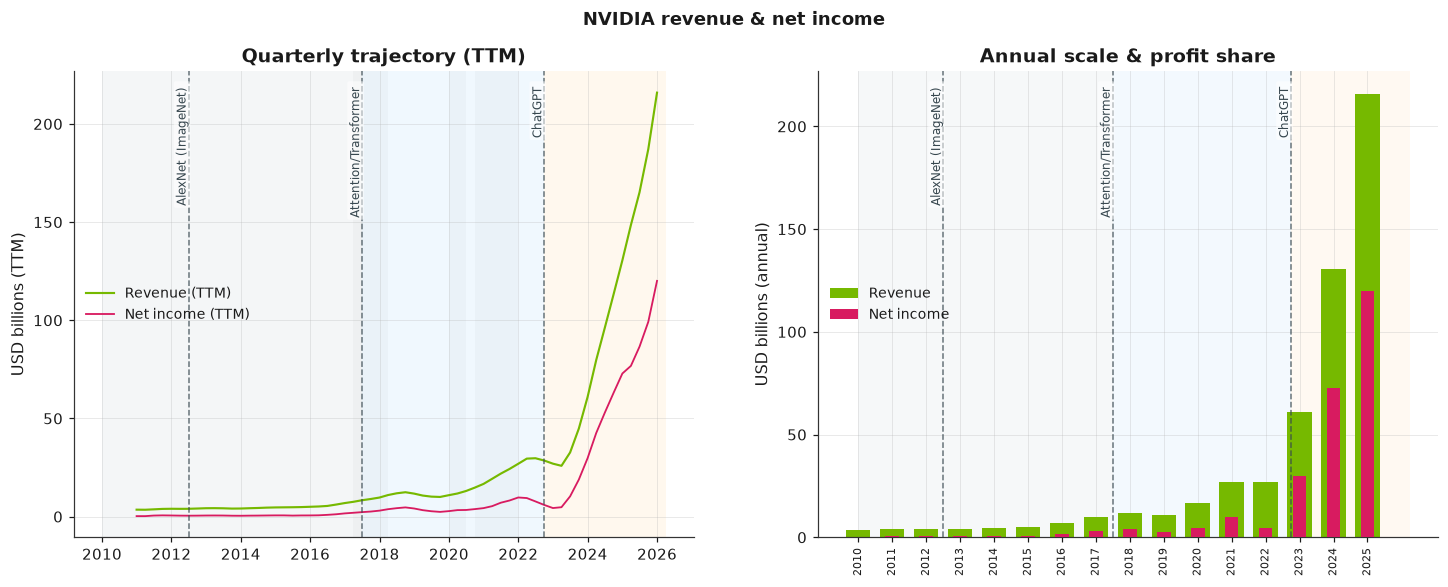

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT: current TTM lines
r = common.ticker_series(panel, "NVDA", "revenue_ttm")
n = common.ticker_series(panel, "NVDA", "netincome_ttm")
ax1.plot(r["date"], r["revenue_ttm"]/1e9, color=common.color("NVDA"), lw=1.4, label="Revenue (TTM)")
ax1.plot(n["date"], n["netincome_ttm"]/1e9, color="#d81b60", lw=1.2, label="Net income (TTM)")
common.annotate(ax1); common.style_time_axis(ax1)
ax1.set_ylabel("USD billions (TTM)")
ax1.set_title("Quarterly trajectory (TTM)")
ax1.legend(loc="center left")

# RIGHT: nested annual bars
nvq = panel[panel.ticker == "NVDA"].copy()
nvq["year"] = nvq["calendar_quarter"].str[:4].astype(int)
nvq = nvq.dropna(subset=["revenue", "net_income"])
cnt = nvq.groupby("year")["revenue"].size()
yy = cnt[cnt == 4].index
gg = nvq[nvq.year.isin(yy)].groupby("year")[["revenue", "net_income"]].sum()/1e9
yrs = gg.index.values
common.add_era_bands_year(ax2); common.add_milestones_year(ax2, label=True)
ax2.bar(yrs, gg["revenue"], width=0.72, color=common.color("NVDA"), label="Revenue", zorder=2)
ax2.bar(yrs, gg["net_income"], width=0.40, color="#d81b60", label="Net income", zorder=3)
ax2.set_xticks(yrs); ax2.set_xticklabels([str(y) for y in yrs], rotation=90, fontsize=7)
ax2.set_ylabel("USD billions (annual)")
ax2.set_title("Annual scale & profit share")
ax2.legend(loc="center left")

fig.suptitle("NVIDIA revenue & net income", fontweight="bold")
save(fig, "02_revenue_compare"); plt.show()

Trailing-twelve-month revenue and net income are shown as quarterly lines (left) and as annual bars with net income nested inside revenue (right). Both series are slow and roughly linear through the Pre-Attention era, ending near \$8B revenue and \$2B net income. They accelerate through the Transformer era (about \$29B and \$6B by its end) and rise steeply in the Generative-AI era, where trailing revenue reaches roughly \$216B and net income roughly \$120B.

The nested-bar panel adds a reading the lines alone do not give: the magenta net-income block fills a steadily larger fraction of each green revenue bar, so profitability is deepening at the same time as revenue is growing. The steepest change in both magnitude and profit share falls inside the Generative-AI band that opens at the 2022Q4 marker. This is the same inflection visible in the price chart (01) and the margin chart (04), and the revenue series here is the raw material for the structural-break tests planned in the diagnostic notebook (RQ2).

A few cautions. The series are trailing-twelve-month, so they are smoothed and lag the underlying quarter by up to a year; sharp turns in the chart are gentler than the single-quarter reality. The right panel's nesting is honest only because net income is always a subset of revenue, so it should not be read as two independent quantities. And the close timing between the revenue surge and the ChatGPT marker is alignment in this descriptive view, with the formal test of whether a break sits at that date left to the diagnostic chapter.

Segment mix (annual). Watch **Data Center** overtake **Gaming** and then dominate through the Gen-AI band; this single chart subsumes the old standalone share-line, which showed the same crossover. Year ticks align under each bar.

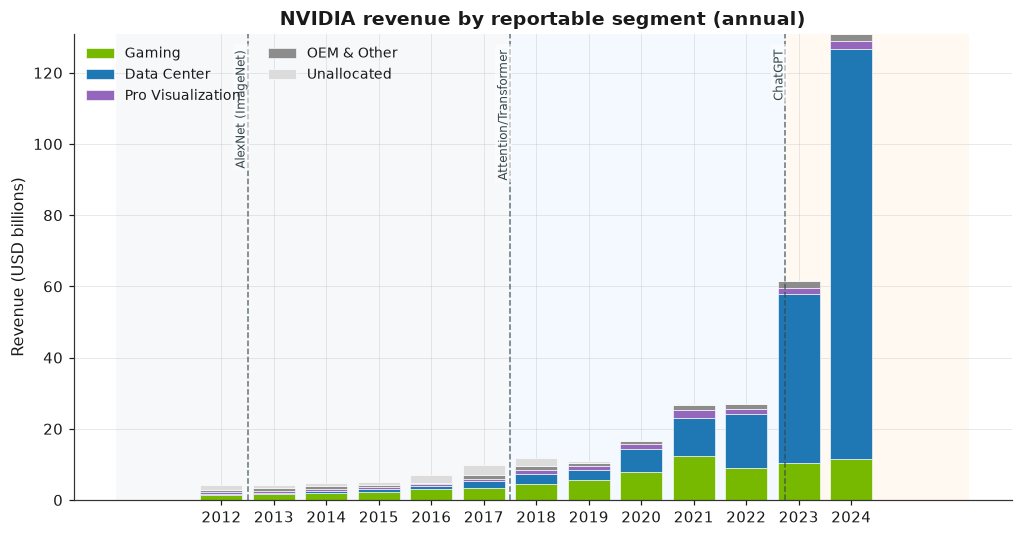

In [20]:
fig, ax = plt.subplots()
bands = list(common.SEGMENT_COLORS.keys())
years = seg["calendar_year"].astype(int).values
bottom = np.zeros(len(seg))
for b in bands:
    h = (seg[b]/1e3).values
    ax.bar(years, h, bottom=bottom, width=0.8, color=common.SEGMENT_COLORS[b],
           label=common.SEGMENT_LABELS[b], edgecolor="white", linewidth=0.4, zorder=2)
    bottom += h
common.add_era_bands_year(ax); common.add_milestones_year(ax)
ax.set_xticks(years); ax.set_xticklabels([str(y) for y in years], rotation=0)
ax.set_ylabel("Revenue (USD billions)")
ax.set_title("NVIDIA revenue by reportable segment (annual)")
ax.legend(loc="upper left", ncol=2)
save(fig, "03_nvda_segments"); plt.show()

NVIDIA's annual revenue by reportable segment shows the business changing shape. Through the mid-2010s, Gaming is the largest band by a wide margin (for example \$3.0B Gaming against \$0.8B Data Center in 2016). Data Center then climbs steadily and overtakes Gaming in calendar 2022, at roughly \$15.0B against \$9.1B, before pulling far ahead at \$47.5B in 2023 and \$115.2B in 2024, while Gaming stays roughly flat in the \$9B to \$12B range.

The crossover year is the chart's anchor. Calendar 2022 maps to NVIDIA's fiscal 2023 and lines up directly with the 2022Q4 ChatGPT marker, which is the cleanest single temporal alignment in the whole study. This chart subsumes the earlier standalone Data-Center-share line, which told the same story less directly, and it underpins the revenue-mix part of RQ3. The shift from a gaming-led to a data-center-led mix is also the business-level counterpart to the margin re-rating in chart 04, since data-center products carry higher margins.

Cautions specific to this chart. Segments are annual, hand-collected from 10-K filings, and the early years carry a sizeable unallocated band where categories were not separately disclosed, so pre-2017 splits are coarser than they look. One figure (the FY2016 to FY2017 Data Center value) is flagged in the data notes as a possible transcription duplicate pending verification. And the fiscal-to-calendar mapping (fiscal year n is roughly calendar year n minus one) is applied here, so a reader comparing against NVIDIA's own fiscal labelling will see a one-year offset.

Profitability shown as a **revenue decomposition**: each year's bar is 100% of revenue split into cost of revenue, operating expenses, other (tax/interest), and net income. The cumulative tops *are* the margins: top of **Net income** = net margin, **+Other** = operating margin, **+Operating expenses** = gross margin. (Stacking the three margins directly would be invalid because they are nested, so this is the correct way to see all three at once.)

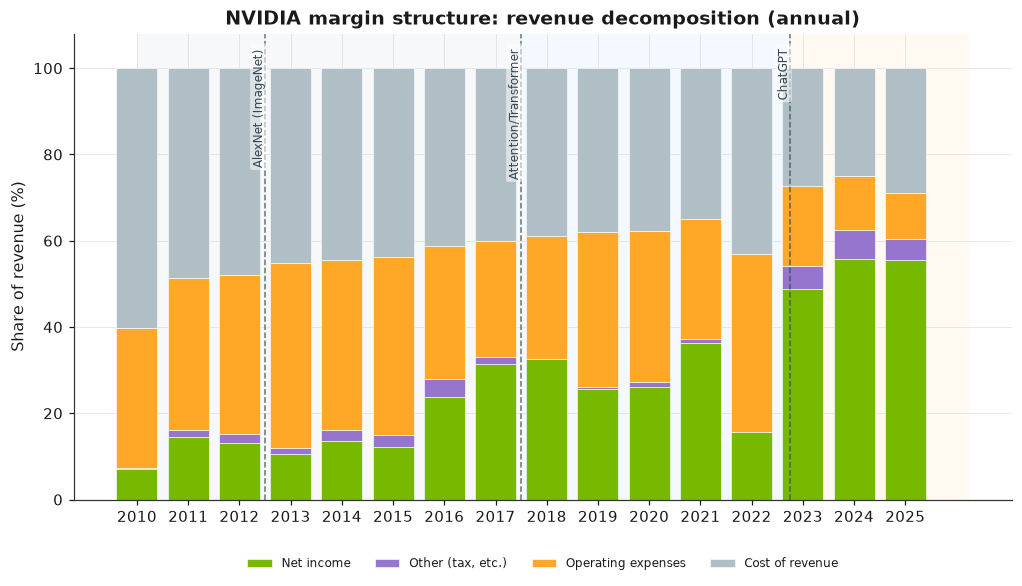

In [21]:
nvq = panel[panel.ticker == "NVDA"].copy()
nvq["year"] = nvq["calendar_quarter"].str[:4].astype(int)
cols = ["revenue", "gross_profit", "operating_income", "net_income"]
nvq = nvq.dropna(subset=cols)
full = nvq.groupby("year")["revenue"].size()
yrs = full[full == 4].index                      # complete fiscal years only
g = nvq[nvq.year.isin(yrs)].groupby("year")[cols].sum()
rev = g["revenue"]

layers = [
    ("Net income",         g["net_income"] / rev * 100,                            common.color("NVDA")),
    ("Other (tax, etc.)",  (g["operating_income"] - g["net_income"]) / rev * 100,  "#9575cd"),
    ("Operating expenses", (g["gross_profit"] - g["operating_income"]) / rev * 100, "#ffa726"),
    ("Cost of revenue",    (rev - g["gross_profit"]) / rev * 100,                  "#b0bec5"),
]
years = g.index.values
fig, ax = plt.subplots()
bottom = np.zeros(len(years))
for name, vals, col in layers:
    ax.bar(years, vals.values, bottom=bottom, width=0.8, color=col,
           label=name, edgecolor="white", linewidth=0.4, zorder=2)
    bottom += vals.values
common.add_era_bands_year(ax); common.add_milestones_year(ax, label=True)
ax.set_xticks(years); ax.set_xticklabels([str(y) for y in years], rotation=0)
ax.set_ylim(0, 108)
ax.set_ylabel("Share of revenue (%)")
ax.set_title("NVIDIA margin structure: revenue decomposition (annual)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=8, frameon=False)
save(fig, "04_nvda_margin_structure"); plt.show()

Each annual bar decomposes a year of NVIDIA revenue into four shares that sum to 100 percent: cost of revenue, operating expenses, other (tax and interest), and net income. The cumulative boundaries are the margins, so the top of the net-income block is the net margin, adding the other block gives the operating margin, and adding operating expenses gives the gross margin. The net-income share rises from roughly 7 percent in 2010 to about 56 percent in 2025, while the cost-of-revenue share shrinks, which is the same as saying the gross margin rises. Aggregated by era, the net margin moves from 16 to 28 to 54 percent and the gross margin from 54 to 61 to 72 percent.

The chart's value is that it shows all three margins at once and ties them to a single quantity, revenue. The steepest re-rating sits in the Generative-AI band, and it coincides with the segment shift in chart 03: as data-center products displace gaming in the mix, a larger share of each revenue dollar survives to the bottom line. This is the profitability counterpart to RQ3 and feeds the era table in the synthesis.

Cautions. Stacking the three margins directly would be invalid because they are nested, which is exactly why this chart uses the revenue decomposition instead, so readers should not add the margin numbers together. The bars are annual aggregates, so within-year swings are hidden. And as elsewhere, the alignment of the margin step-up with the Generative-AI era is descriptive: the mix shift is a plausible mechanism, but this chart documents the co-timing rather than proving it.

## 2. Peer divergence

How NVIDIA separates from AMD, Intel, and the market benchmarks across price, revenue, return correlation, margin, and revenue share, as the revenue model shifts toward data center. The last three are era-aggregated bars; the rest are time series.

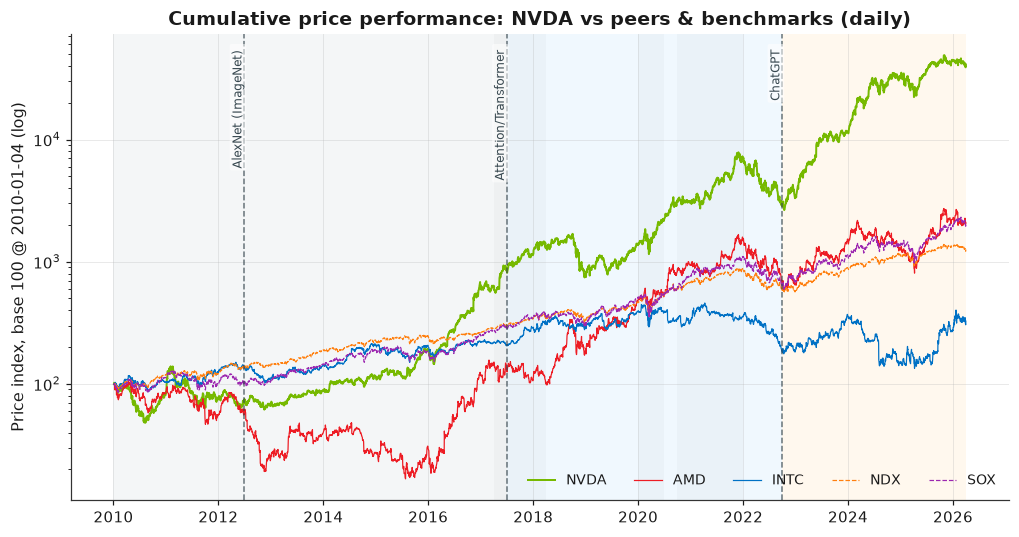

In [22]:
fig, ax = plt.subplots()
idx = common.daily_index(daily, ["NVDA", "AMD", "INTC", "NDX", "SOX"])
for tk in idx.columns:
    ax.plot(idx.index, idx[tk], color=common.color(tk),
            lw=1.3 if tk == "NVDA" else 0.8,
            ls="--" if tk in common.BENCHMARKS else "-", label=tk)
common.annotate(ax)
common.set_log(ax); common.style_time_axis(ax)
ax.set_ylabel("Price index, base 100 @ 2010-01-04 (log)")
ax.set_title("Cumulative price performance: NVDA vs peers & benchmarks (daily)")
ax.legend(ncol=5, loc="lower right")
save(fig, "05_peer_price_index"); plt.show()

Cumulative price performance is indexed to 100 at the start of 2010 and plotted on a log scale for NVIDIA, AMD, Intel, and the two benchmarks (the Nasdaq-100 and the PHLX Semiconductor Index). For most of the first decade the five series move in a broadly similar band. NVIDIA then separates from the group and pulls decisively ahead, ending far above every comparator, with the gap widening through the Generative-AI era.

The chart's job is relative, not absolute: it asks how an investment in NVIDIA would have compounded against the alternatives, and the answer is that the divergence opens up well before the generative-AI wave and then accelerates within it. This is consistent with the relative-strength chart (06), which isolates the same outperformance against the benchmarks, and with the return-correlation chart (08), where NVIDIA still moves with the market even as it outpaces it. Together these support RQ1's framing of peer divergence.

Cautions. A log scale compresses the visual gap, so the late outperformance is even larger in proportional terms than it looks. Index charts are sensitive to the start date; rebasing to 2015 or 2017 would change the apparent magnitudes though not the ordering. And cumulative price performance is not risk-adjusted, so it says nothing about the volatility an investor would have lived through, which the drawdowns visible in the Generative-AI band only hint at.

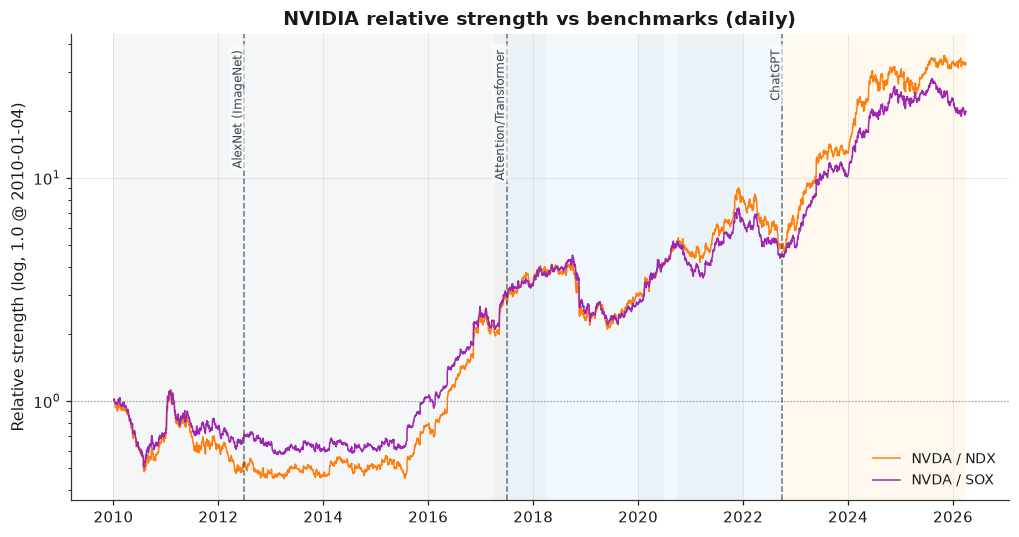

In [23]:
fig, ax = plt.subplots()
idx = common.daily_index(daily, ["NVDA", "NDX", "SOX"])
for bench in ["NDX", "SOX"]:
    ax.plot(idx.index, idx["NVDA"]/idx[bench], color=common.color(bench), lw=1.0, label=f"NVDA / {bench}")
ax.axhline(1, color="#999", lw=0.8, ls=":")
common.annotate(ax, milestone_labels=True)
common.set_log(ax); common.style_time_axis(ax)
ax.set_ylabel("Relative strength (log, 1.0 @ 2010-01-04)")
ax.set_title("NVIDIA relative strength vs benchmarks (daily)")
ax.legend(loc="lower right")
save(fig, "06_relative_strength"); plt.show()

This chart divides NVIDIA's price index by each benchmark's, so a rising line means NVIDIA is outpacing that benchmark and a value of 1.0 means they have matched since the 2010 base. NVIDIA spends the early Pre-Attention era below 1.0, underperforming both the Nasdaq-100 and the semiconductor index, and falls as low as 0.45 against the Nasdaq-100 in 2013. It crosses back above 1.0 for good around May 2016, then climbs steadily and surges in the Generative-AI era to roughly 32 times the Nasdaq-100.

The value here is timing. By stripping out the broad market, the chart shows that NVIDIA's genuine outperformance begins around 2016, between the AlexNet and Attention/Transformer markers, rather than waiting for ChatGPT. That earlier inflection echoes the log panel of chart 01 and complements the absolute view in chart 05. For RQ1 and RQ4 it is evidence that the repricing relative to the market started in the developmental-scaling phase and then intensified, rather than appearing all at once in 2022.

Cautions. Relative strength is a ratio of two indices, so it inherits the start-date sensitivity of both, and the early sub-1.0 readings reflect the 2010 base as much as any real weakness. The metric is unitless and says nothing about absolute returns. And the crossover date describes when the ratio turned, not a claim that any particular milestone moved it.

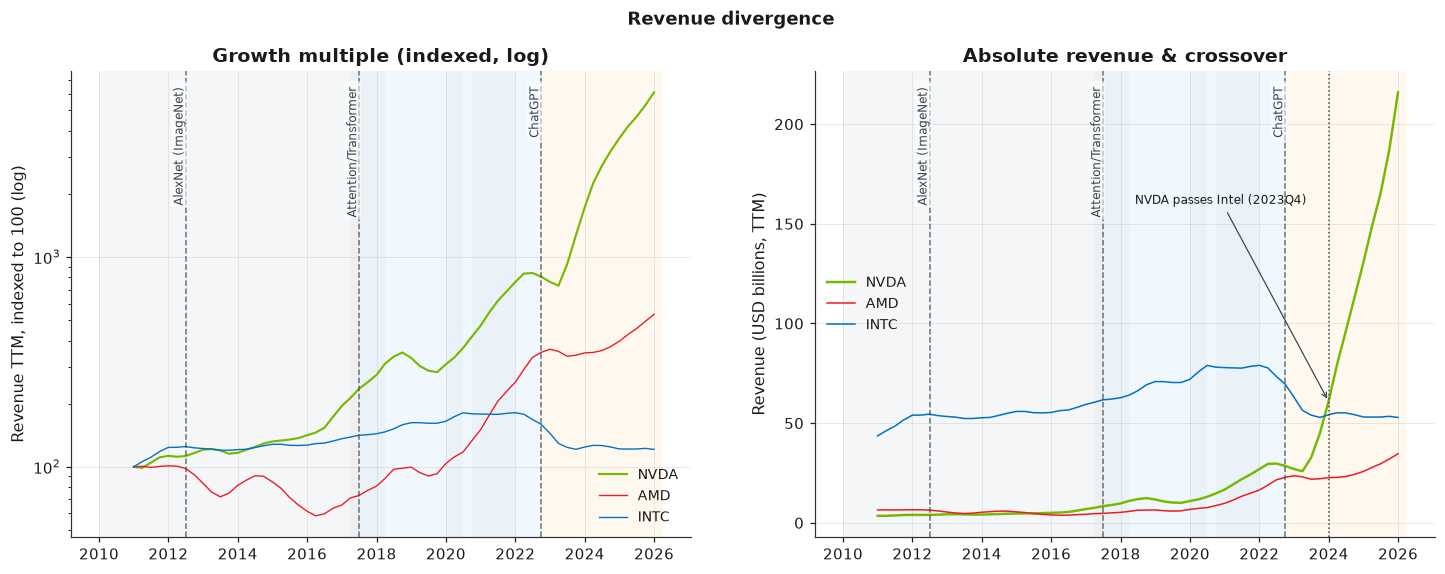

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT: indexed growth (log)
for tk in ["NVDA", "AMD", "INTC"]:
    s = common.ticker_series(panel, tk, "revenue_ttm")
    ax1.plot(s["date"], s["revenue_ttm"]/s["revenue_ttm"].iloc[0]*100,
             color=common.color(tk), lw=1.4 if tk == "NVDA" else 0.9, label=tk)
common.annotate(ax1); common.set_log(ax1); common.style_time_axis(ax1)
ax1.set_ylabel("Revenue TTM, indexed to 100 (log)")
ax1.set_title("Growth multiple (indexed, log)")
ax1.legend(loc="lower right")

# RIGHT: absolute $B and crossover (linear)
piv = panel.pivot_table(index="date", columns="ticker", values="revenue_ttm")
for tk in ["NVDA", "AMD", "INTC"]:
    s = common.ticker_series(panel, tk, "revenue_ttm")
    ax2.plot(s["date"], s["revenue_ttm"]/1e9, color=common.color(tk),
             lw=1.6 if tk == "NVDA" else 1.0, label=tk)
cx = piv[piv["NVDA"] > piv["INTC"]].index
if len(cx):
    d0 = cx.min()
    ax2.axvline(d0, color="#37474f", ls=":", lw=1)
    ax2.annotate(f"NVDA passes Intel ({d0.year}Q{(d0.month-1)//3+1})",
                 xy=(d0, piv.loc[d0, "NVDA"]/1e9),
                 xytext=(pd.Timestamp("2018-06-01"), 160), textcoords="data",
                 fontsize=8, ha="left",
                 arrowprops=dict(arrowstyle="->", color="#37474f", lw=0.8))
common.annotate(ax2, milestone_labels=True); common.style_time_axis(ax2)
ax2.set_ylabel("Revenue (USD billions, TTM)")
ax2.set_title("Absolute revenue & crossover")
ax2.legend(loc="center left")

fig.suptitle("Revenue divergence", fontweight="bold")
save(fig, "07_revenue_compare"); plt.show()

Peer revenue is shown two ways. The left panel indexes trailing revenue to 100 at 2010 on a log scale, where NVIDIA ends roughly fifty times its starting revenue against low-single-digit multiples for AMD and Intel. The right panel plots the same series in absolute dollars, where the headline is a crossover: NVIDIA's trailing revenue passes Intel's for the first time at 2023Q4, after sitting below it for the entire prior decade, and then leaves it behind.

Keeping both panels is deliberate, because they answer different questions. The indexed panel measures growth multiple, useful for RQ4's cyclicality-versus-structural-growth question; the absolute panel locates the moment of overtaking, which is the more concrete fact. The 2023Q4 crossover sits just inside the Generative-AI band and is the revenue-side echo of the price divergence in chart 05 and the share reversal in chart 10. This is the levels-based view of divergence that we rely on instead of revenue-growth correlation, which proved too fragile to trust.

Cautions. Revenue is trailing-twelve-month and therefore smoothed, so the crossover quarter is approximate to within a couple of quarters. Indexing to 2010 flatters whichever company started smallest, so the fifty-times figure should be read as a growth multiple from a low base, not a statement about size. And Intel's and NVIDIA's revenues are not like-for-like, since Intel's is mostly CPUs and NVIDIA's increasingly GPUs, so the crossover compares total company revenue rather than competition in a single market.

Return correlation, summarized to **one figure per era per pair** (daily log-returns *within* each era) instead of a rolling line. Each bar rests on ~900–1,900 trading days, so it's a stable estimate, and the headline is unmistakable: NVIDIA's correlation with **Intel** falls sharply era over era (0.46 → 0.59 → 0.32) while its tie to the **Nasdaq-100** stays high (~0.76). The tradeoff vs. the rolling line is that within-era *timing* is no longer visible.

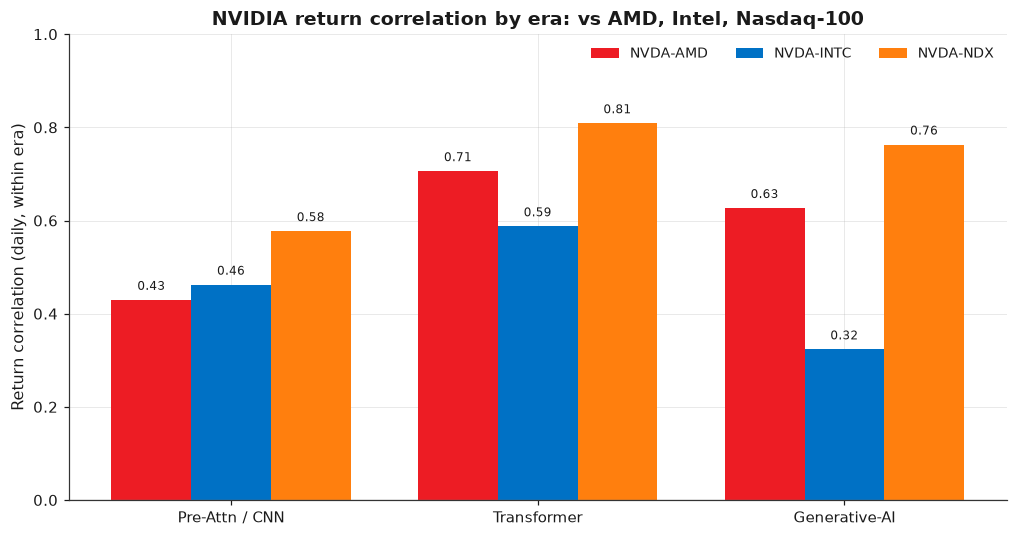

In [25]:
px = daily.pivot_table(index="date", columns="ticker", values="adj_close").sort_index()
rets = np.log(px).diff()
pairs = ["AMD", "INTC", "NDX"]
corr_era = {tk: [] for tk in pairs}
for era in common.ERAS:
    sub = rets.loc[(rets.index >= era.start) & (rets.index <= era.end)]
    for tk in pairs:
        corr_era[tk].append(sub["NVDA"].corr(sub[tk]))

x = np.arange(len(common.ERAS)); w = 0.26
fig, ax = plt.subplots()
for i, tk in enumerate(pairs):
    bars = ax.bar(x + (i - 1) * w, corr_era[tk], width=w, color=common.color(tk), label=f"NVDA-{tk}")
    for b, v in zip(bars, corr_era[tk]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="#999", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylabel("Return correlation (daily, within era)")
ax.set_title("NVIDIA return correlation by era: vs AMD, Intel, Nasdaq-100")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", ncol=3)
save(fig, "08_correlation_by_era"); plt.show()

For each era, a single Pearson correlation of daily log-returns is computed between NVIDIA and each of AMD, Intel, and the Nasdaq-100, using every trading day in the era (roughly 900 to 1,900 days per bar). NVIDIA's correlation with Intel falls across the three eras, from 0.46 to 0.59 to 0.32, while its correlation with the Nasdaq-100 stays high throughout at about 0.58, 0.81, and 0.76. The correlation with AMD stays moderate to high (0.43, 0.71, 0.63).

The reading for RQ1 is decoupling from the legacy peer alongside continued co-movement with the market: by the Generative-AI era NVIDIA's daily returns track the Nasdaq-100 more than twice as closely as they track Intel. Each bar pools the whole era rather than averaging rolling windows, which is the statistically cleaner estimator and avoids the bias of averaging correlation coefficients. The era-bar format trades away within-era timing, the one thing the older rolling line showed, in exchange for stability and readability.

Cautions. A single number per era cannot say when within the Generative-AI era the Intel correlation fell, only that it was low on average across it. Correlation of returns measures co-movement, not relative performance, so a high market correlation is fully compatible with the large outperformance seen in charts 05 and 06. We deliberately restrict this correlation analysis to returns, which have hundreds of observations per era; the equivalent on revenue growth was tested and dropped, because thirteen quarters made it unstable and it conflated shared business-cycle timing with genuine co-movement.

Margin comparison across the three companies, aggregated to one figure per era (era total gross profit / era total revenue) so quarterly shocks don't clutter the picture. This is the visual twin of the synthesis era table.

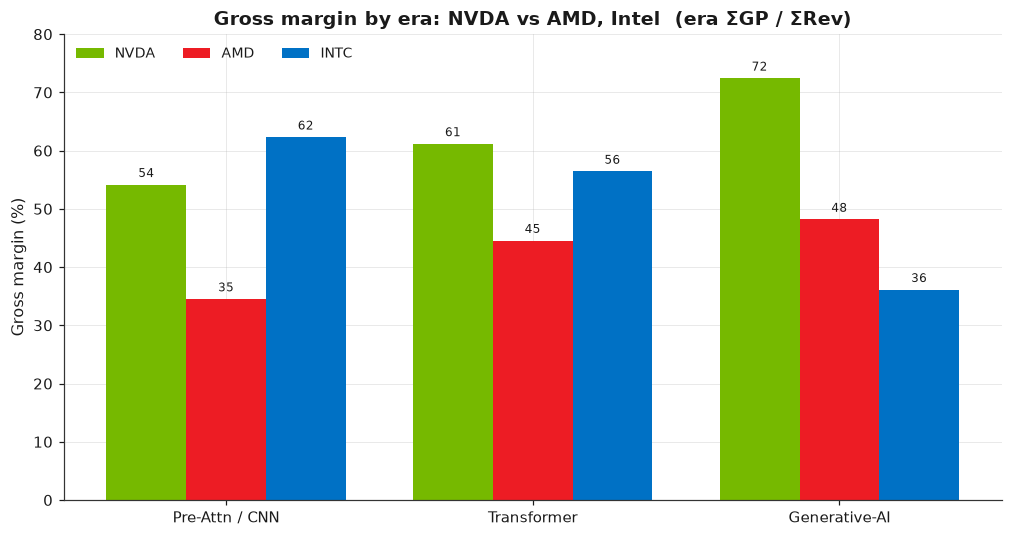

In [26]:
tickers = ["NVDA", "AMD", "INTC"]
eras = [e.name for e in common.ERAS]
gm_era = {tk: [panel[(panel.ticker == tk) & (panel.era == e)]["gross_profit"].sum()
               / panel[(panel.ticker == tk) & (panel.era == e)]["revenue"].sum() * 100
               for e in eras] for tk in tickers}

x = np.arange(len(eras)); w = 0.26
fig, ax = plt.subplots()
for i, tk in enumerate(tickers):
    bars = ax.bar(x + (i - 1) * w, gm_era[tk], width=w, color=common.color(tk), label=tk)
    for b, v in zip(bars, gm_era[tk]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.0f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylabel("Gross margin (%)")
ax.set_title("Gross margin by era: NVDA vs AMD, Intel  (era ΣGP / ΣRev)")
ax.legend(loc="upper left", ncol=3)
ax.set_ylim(0, 80)
save(fig, "09_gross_margin_by_era"); plt.show()

Gross margin is aggregated to one figure per company per era, computed as era total gross profit over era total revenue so that quarterly noise does not clutter the comparison. NVIDIA rises across the eras, 54 to 61 to 72 percent. AMD rises more modestly, 35 to 45 to 48 percent. Intel moves the other way, 62 to 56 to 36 percent, so the company with the highest gross margin in the Pre-Attention era has the lowest by the Generative-AI era.

The chart's point is the widening gap and the NVIDIA-Intel crossover, which together describe a reversal of margin leadership that lines up with the same eras as the revenue and share reversals in charts 07 and 10. It is the cross-company counterpart to NVIDIA's own margin re-rating in chart 04, and it supports the competitive-repositioning part of RQ3. The era aggregation here is the visual twin of the synthesis era table.

Cautions. Gross margin reflects product mix and pricing power and says nothing about operating efficiency or net profitability, which the decomposition in chart 04 covers. Era aggregation hides the within-era path, so a company that ended an era very differently from how it began is summarised by one bar. And the comparison mixes different product markets, so Intel's margin decline reflects its own CPU business rather than direct displacement by NVIDIA.

Each firm's share of the **three companies' combined revenue**, by era (era-total revenue). Read this as relative size among the three, **not** product-market share: most of Intel's revenue is CPUs and NVIDIA's is GPUs, so it mixes different markets. Even so, the reversal is stark: Intel's share falls from ~84% to ~26% while NVIDIA's climbs from ~8% to ~61%.

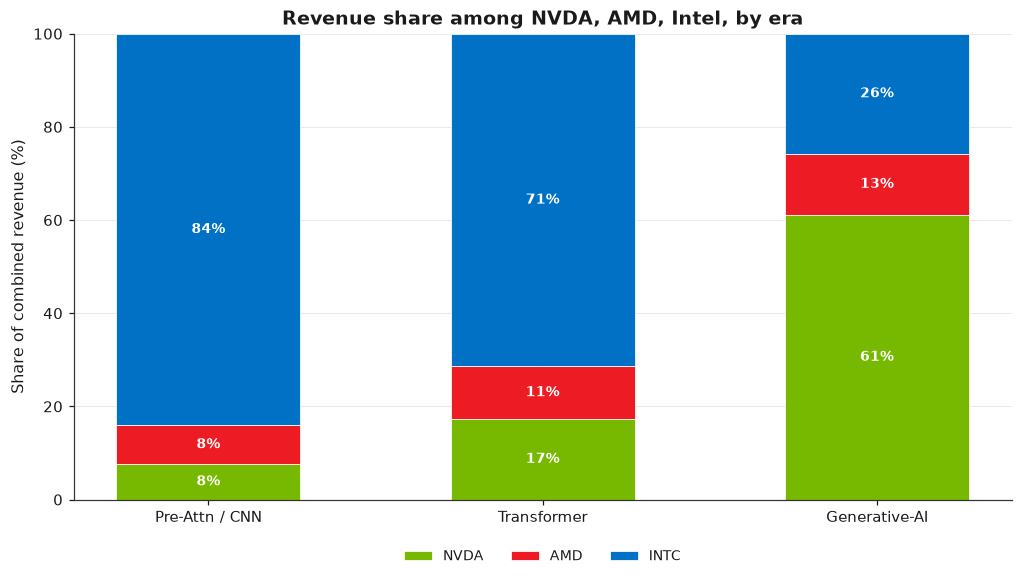

In [27]:
tickers = ["NVDA", "AMD", "INTC"]
eras = [e.name for e in common.ERAS]
share = {tk: [] for tk in tickers}
for e in eras:
    sub = panel[(panel.ticker.isin(tickers)) & (panel.era == e)]
    tot = {tk: sub[sub.ticker == tk]["revenue"].sum() for tk in tickers}
    s = sum(tot.values())
    for tk in tickers:
        share[tk].append(tot[tk] / s * 100)

x = np.arange(len(eras))
fig, ax = plt.subplots()
bottom = np.zeros(len(eras))
for tk in tickers:
    vals = np.array(share[tk])
    ax.bar(x, vals, bottom=bottom, width=0.55, color=common.color(tk),
           label=tk, edgecolor="white", linewidth=0.5)
    for xi, v, b0 in zip(x, vals, bottom):
        if v > 4:
            ax.text(xi, b0 + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylim(0, 100)
ax.set_ylabel("Share of combined revenue (%)")
ax.set_title("Revenue share among NVDA, AMD, Intel, by era")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
save(fig, "10_revenue_share_by_era"); plt.show()

Among the three companies only, each era's bar splits combined revenue into the three firms' shares. The reversal is near-total: Intel falls from 84 to 71 to 26 percent, NVIDIA rises from 8 to 17 to 61 percent, and AMD drifts up modestly from 8 to 11 to 13 percent. The company that was more than four-fifths of the three-firm pool in the Pre-Attention era is roughly a quarter of it by the Generative-AI era, and the positions of NVIDIA and Intel are essentially swapped.

This is the most dramatic single picture of competitive repositioning in the study and a centrepiece of RQ3. It is the share-based companion to the absolute crossover in chart 07 and the margin reversal in chart 09: where those show levels and profitability, this shows relative size within the group. The concentration of the change in the Generative-AI band lines up with the segment shift in chart 03.

This chart needs the firmest caution in the set: it is share of these three companies' combined revenue, not market share in any real product market. Intel's revenue is mostly CPUs and NVIDIA's increasingly GPUs, so the pool mixes different businesses, and the 84 percent early figure mainly reflects Intel being a far larger company at the time rather than holding 84 percent of anything NVIDIA competed for. Read it as relative size among three chosen firms, and take true market-share claims from dedicated industry sources instead.

## 3. Capex linkage

The demand backdrop: aggregate hyperscaler capital expenditure (Microsoft, Alphabet, Amazon, Meta) against NVIDIA's revenue. Formal lead/lag cross-correlation is left to the diagnostic notebook; here we show the co-movement.

Both series are in the **same unit** (USD billions), so they share **one scale**, and the right axis only mirrors the left. This is deliberate: an independent dual axis can be rescaled to slide two lines into spurious alignment, which is a common way these charts mislead. A shared scale keeps the comparison honest. Read truthfully, hyperscaler capex sits *above* NVIDIA's revenue throughout, with NVIDIA closing from roughly 18% of the four firms' combined capex (through 2022) to about 57% by 2025, capturing a fast-growing share, not matching it 1:1.

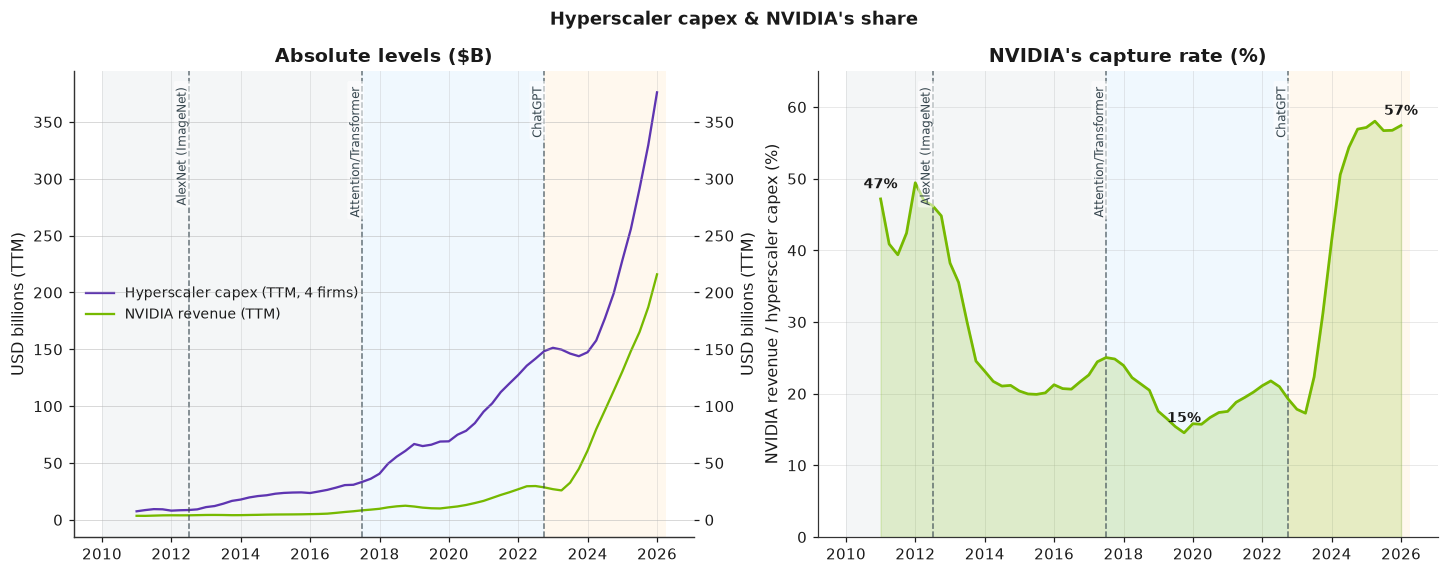

In [28]:
cap = panel[panel.ticker.isin(common.HYPERSCALERS)].pivot_table(
    index="date", columns="ticker", values="capex")
cap_ttm = cap.sum(axis=1, min_count=1).rolling(4).sum()
nr = common.ticker_series(panel, "NVDA", "revenue_ttm").set_index("date")["revenue_ttm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT: shared-scale mirrored lines
ax1.plot(cap_ttm.index, cap_ttm/1e9, color="#5e35b1", lw=1.5, label="Hyperscaler capex (TTM, 4 firms)")
ax1.plot(nr.index, nr/1e9, color=common.color("NVDA"), lw=1.5, label="NVIDIA revenue (TTM)")
common.add_era_bands(ax1); common.add_milestones(ax1, label=True)
common.style_time_axis(ax1)
ax1.set_ylabel("USD billions (TTM)")
ax1b = ax1.twinx(); ax1b.set_ylim(ax1.get_ylim()); ax1b.set_ylabel("USD billions (TTM)")
ax1.set_title("Absolute levels ($B)")
ax1.legend(loc="center left")

# RIGHT: capture rate (full 2010-2026 range)
rate = (nr/cap_ttm*100).dropna()
common.add_era_bands(ax2); common.add_milestones(ax2, label=True)
ax2.fill_between(rate.index, rate.values, color=common.color("NVDA"), alpha=0.18, zorder=1)
ax2.plot(rate.index, rate.values, color=common.color("NVDA"), lw=1.8, zorder=2)
trough = rate.idxmin()
for d in [rate.index[0], trough, rate.index[-1]]:
    ax2.annotate(f"{rate.loc[d]:.0f}%", xy=(d, rate.loc[d]), xytext=(0, 7),
                 textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color="#1a1a1a")
common.style_time_axis(ax2); ax2.set_ylim(0, 65); ax2.set_xlim(ax1.get_xlim())
ax2.set_ylabel("NVIDIA revenue / hyperscaler capex (%)")
ax2.set_title("NVIDIA's capture rate (%)")

fig.suptitle("Hyperscaler capex & NVIDIA's share", fontweight="bold")
save(fig, "11_capex_compare"); plt.show()

The left panel plots aggregate trailing capital expenditure for the four large hyperscalers (Microsoft, Alphabet, Amazon, Meta) against NVIDIA's trailing revenue on a shared dollar scale. The right panel divides the two to give a capture rate, NVIDIA revenue as a percentage of hyperscaler capex. Both absolute series rise throughout, with hyperscaler capex sitting above NVIDIA revenue the whole way. The capture rate traces a U: roughly 47 percent in 2011, down to about 15 percent around 2019 to 2020, and back up to about 57 percent by 2025.

The two panels answer different questions, which is why both are kept. The left shows scale and the persistent gap; the right shows how large a slice of the build-out NVIDIA's revenue corresponds to. The U-shape is the more interesting story: NVIDIA was a large fraction of a small early cloud-capex base, fell as hyperscalers scaled spending on non-GPU infrastructure, then recovered sharply in the Generative-AI era as GPUs became central to that spending, with the upturn aligning with the 2022Q4 marker. This is the demand-backdrop evidence for RQ5.

Cautions, and this chart needs several. The shared scale is deliberate, because an independent dual axis can be rescaled to manufacture alignment between two lines; the mirror axis here adds no information and exists only to make that honesty explicit. The capture rate is a ratio of NVIDIA's total revenue to total hyperscaler capex, not a claim that hyperscalers buy that share of NVIDIA or that NVIDIA sells only to them, so it is a rough co-movement indicator rather than a supply figure. The early-period values reflect a small capex denominator and should be read with that in mind. And capex is the only hyperscaler series in the panel, since their revenue and margins are intentionally not pulled.

## Synthesis: era comparison

A compact per-era summary for NVIDIA. This table and a written narrative belong in `findings/`.

In [29]:
rows = []
nv = panel[panel.ticker == "NVDA"]
for era in common.ERAS:
    e = nv[nv.era == era.name]
    rows.append({
        "Era": era.name,
        "Quarters": len(e),
        "Price idx (end)": round(e["price_index_100"].dropna().iloc[-1]) if e["price_index_100"].notna().any() else None,
        "Revenue TTM end ($B)": round(e["revenue_ttm"].dropna().iloc[-1]/1e9, 1) if e["revenue_ttm"].notna().any() else None,
        "Avg gross margin (%)": round(e["gross_margin"].mean()*100, 1),
        "Avg QoQ return (%)": round(e["qoq_return"].mean()*100, 1),
    })
era_table = pd.DataFrame(rows)
era_table

,Era,Quarters,Price idx (end),Revenue TTM end ($B),Avg gross margin (%),Avg QoQ return (%)
0,Pre-Attention / CNN,30,895,8.3,52.9,9.7
1,Transformer,21,3040,28.6,61.1,10.0
2,Generative-AI,14,43731,215.9,71.6,24.7


---
### Findings and research-question map

Read era by era, the descriptive story is consistent across every series. In the Pre-Attention / CNN era NVIDIA is a mid-sized, gaming-led, cyclical chip company: below the market in relative strength, a single-digit share of the three-firm revenue pool, and middling margins. Through the Transformer era the price, revenue, and margins all begin to lift and NVIDIA pulls ahead of the market, but it is still the smaller firm in absolute revenue. In the Generative-AI era every series inflects together: price goes near-vertical, Data Center overtakes Gaming, revenue passes Intel's, the margin and revenue-share orderings reverse, and NVIDIA's capture of hyperscaler capex recovers to a majority share. The cleanest single alignment is Data Center overtaking Gaming in calendar 2022, the ChatGPT year. Throughout, these are temporal alignments, not causal claims; the formal break tests live in the diagnostic notebook.

Which charts speak to which research question:

| Research question | Charts |
|---|---|
| **RQ1** Peer correlation and divergence | 05 (price index), 06 (relative strength), 07 (revenue divergence), 08 (return correlation by era) |
| **RQ2** Inflection points in price, revenue, net income | 01 (price), 02 (revenue and net income) set up the series; the structural-break tests are in the diagnostic notebook |
| **RQ3** Revenue mix, margins, competitive share | 03 (segments), 04 (margin structure), 09 (gross margin by era), 10 (revenue share by era) |
| **RQ4** Structural growth versus cyclicality | 01 (price, log panel), 02 (revenue), 06 (relative strength), plus the diagnostic era comparison |
| **RQ5** Milestone timing and demand backdrop | 03 (segment crossover at 2022), 11 (capex and capture rate), and the synthesis era table above |

The polished version of this narrative lives in `findings/findings.md`; the exported figures are in `figures/`.